In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("./Data/processed_csv_dataset.csv")
print("Shape:", df.shape)

display(df.head())

Shape: (76000, 27)


,Unnamed: 0,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,year,month,day,day_of_week,week_of_year,is_weekend,dow_sin,dow_cos,month_sin,month_cos
0,0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
1,1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
2,2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
3,3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
4,4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025


# Creating forecasting features

In [3]:
df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

# Creating historical demand lags.

In [4]:
group = df.groupby(["Store ID", "Product ID"])["Demand"]

df["demand_lag_1"] = group.shift(1)
df["demand_lag_7"] = group.shift(7)
df["demand_lag_14"] = group.shift(14)
df["demand_lag_28"] = group.shift(28)

In [5]:
grouped_demand = df.groupby(["Store ID", "Product ID"])["Demand"]

df["rolling_mean_7"] = (
    grouped_demand
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_14"] = (
    grouped_demand
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

df["rolling_std_7"] = (
    grouped_demand
    .transform(lambda x: x.shift(1).rolling(7).std())
)

### Lag and Rolling Features

Historical demand is one of the strongest sources of information for forecasting.

I created:
- 1-day lag
- 7-day lag
- 14-day lag
- 28-day lag
- 7-day rolling mean
- 14-day rolling mean
- 7-day rolling standard deviation

All rolling features are shifted by one day before calculation to prevent target leakage.

In [6]:
model_df = df.dropna(
    subset=[
        "demand_lag_1",
        "demand_lag_7",
        "demand_lag_14",
        "demand_lag_28",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_std_7"
    ]
).copy()

print("Original rows:", len(df))
print("Rows available for modelling:", len(model_df))

Original rows: 76000
Rows available for modelling: 73200


# Target and features

In [7]:
target = "Demand"

categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numeric_features = [
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",

    "demand_lag_1",
    "demand_lag_7",
    "demand_lag_14",
    "demand_lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",

    "day_of_week",
    "month",
    "day",
    "week_of_year",
    "is_weekend",

    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

features = categorical_features + numeric_features

X = model_df[features]
y = model_df[target]

print("Number of features:", len(features))
print("X-Shape:",X.shape)
print("Y-Shape:",y.shape)

Number of features: 27
X-Shape: (73200, 27)
Y-Shape: (73200,)


# Time-based train/test split

In [8]:
unique_dates = sorted(model_df["Date"].unique())

split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_index]

train_df = model_df[
    model_df["Date"] < train_end_date
].copy()

test_df = model_df[
    model_df["Date"] >= train_end_date
].copy()

print("Training period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

Training period:
2022-01-29 to 2023-09-05

Testing period:
2023-09-06 to 2024-01-30

Training rows: 58500
Testing rows: 14700


In [9]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

### Train/Test Strategy

Because this is time-series data, a chronological split was used instead of a random split.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# LINEAR REGRESSION

In [11]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

# RANDOM FOREST MODEL

In [12]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

# XGBOOST MODEL

In [13]:
from xgboost import XGBRegressor

In [14]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

# EVALUATION FUNCTION

In [15]:
def evaluate_model(y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    # Avoid division by zero in MAPE
    non_zero = y_true != 0

    mape = np.mean(
        np.abs(
            (
                y_true[non_zero]
                - predictions[non_zero]
            )
            /
            y_true[non_zero]
        )
    ) * 100

    return mae, rmse, mape

In [16]:
linear_mae, linear_rmse, linear_mape = evaluate_model(
    y_test,
    linear_predictions
)

rf_mae, rf_rmse, rf_mape = evaluate_model(
    y_test,
    rf_predictions
)

xgb_mae, xgb_rmse, xgb_mape = evaluate_model(
    y_test,
    xgb_predictions
)

In [17]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAPE": [
        linear_mape,
        rf_mape,
        xgb_mape
    ]
})

results = results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    results.style.format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAPE": "{:.2f}%"
    })
)

,Model,MAE,RMSE,MAPE
0,XGBoost,16.54,22.38,24.24%
1,Random Forest,24.35,31.24,38.31%
2,Linear Regression,25.37,32.73,36.77%


In [18]:
best_model_name = results.loc[
    results["MAE"].idxmin(),
    "Model"
]

print(
    f"Best model based on MAE: {best_model_name}"
)

Best model based on MAE: XGBoost


# IMPROVEMENT OVER LINEAR REGRESSION

In [19]:
print("\nImprovement over Linear Regression:")

for model_name, model_mae in [
    ("Random Forest", rf_mae),
    ("XGBoost", xgb_mae)
]:

    improvement = (
        (linear_mae - model_mae)
        / linear_mae
    ) * 100

    print(
        f"{model_name}: "
        f"{improvement:.2f}% lower MAE"
    )


Improvement over Linear Regression:
Random Forest: 4.00% lower MAE
XGBoost: 34.80% lower MAE


# ACTUAL VS PREDICTED

In [20]:
comparison = test_df[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Demand"
    ]
].copy()

comparison["Linear Regression"] = (
    linear_predictions
)

comparison["Random Forest"] = (
    rf_predictions
)

comparison["XGBoost"] = (
    xgb_predictions
)

display(
    comparison.head(20)
)

,Date,Store ID,Product ID,Demand,Linear Regression,Random Forest,XGBoost
613,2023-09-06,S001,P0001,115,107.040413,104.580549,102.636765
614,2023-09-07,S001,P0001,103,88.231033,88.843693,86.775764
615,2023-09-08,S001,P0001,96,87.255272,87.259006,86.041870
616,2023-09-09,S001,P0001,80,84.574097,82.126271,84.810555
617,2023-09-10,S001,P0001,164,93.832016,87.515519,97.314789
618,2023-09-11,S001,P0001,108,137.575447,126.808715,124.308365
619,2023-09-12,S001,P0001,83,97.297821,92.237394,90.347595
620,2023-09-13,S001,P0001,108,114.494034,109.166181,103.212463
621,2023-09-14,S001,P0001,133,136.698807,127.608626,128.160522
622,2023-09-15,S001,P0001,49,121.670776,119.258570,110.158485


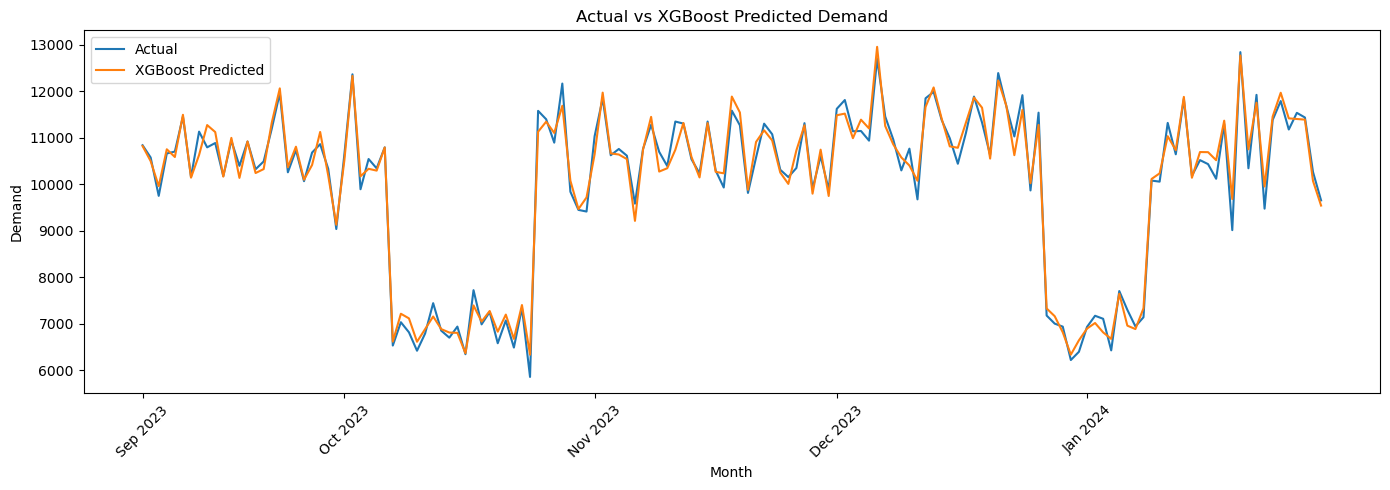

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure Date is datetime
comparison["Date"] = pd.to_datetime(comparison["Date"])

daily_comparison = (
    comparison
    .groupby("Date")[["Demand", "XGBoost"]]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_comparison.index,
    daily_comparison["Demand"],
    label="Actual"
)

plt.plot(
    daily_comparison.index,
    daily_comparison["XGBoost"],
    label="XGBoost Predicted"
)

plt.title("Actual vs XGBoost Predicted Demand")
plt.xlabel("Month")
plt.ylabel("Demand")

# Show only month names
ax = plt.gca()

month_starts = daily_comparison.index.to_series().groupby(
    daily_comparison.index.to_period("M")
).first()

ax.set_xticks(month_starts.values)
ax.set_xticklabels(month_starts.index.strftime("%b %Y"))

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
# SAVE MODEL RESULTS
results.to_csv(
    "./Data/model_comparison.csv",
    index=False
)

# SAVE MODELS

In [31]:
import joblib

joblib.dump(
    linear_model,
    "./models/linear_regression_model.pkl"
)

joblib.dump(
    random_forest_model,
    "./models/random_forest_model.pkl"
)

joblib.dump(
    xgb_model,
    "./models/xgboost_model.pkl"
)

['./models/xgboost_model.pkl']